In [3]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from PIL import Image

# Load a pre-trained Faster R-CNN model
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

# Load an image
image = Image.open('data/pedestrian_day.jpg')
image_tensor = F.to_tensor(image)

# Perform inference
with torch.no_grad():
    prediction = model([image_tensor])

person_label = 1
threshold = 0.5

labels = prediction[0]["labels"]
all_boxes = prediction[0]["boxes"]
all_scores = prediction[0]["scores"]

person_indices = (labels == person_label) & (all_scores > threshold)

boxes = all_boxes[person_indices]
scores = all_scores[person_indices]

# Print the detections for people
print("Boxes:", boxes)
print("Scores:", scores)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Boxes: tensor([[212.9838, 107.0880, 376.8011, 683.6193]])
Scores: tensor([0.9997])


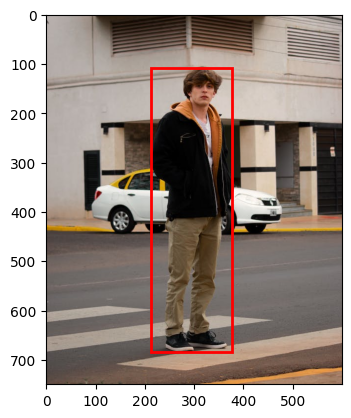

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Convert the image to NumPy
boxes = boxes.numpy()
scores =scores.numpy()

# Create a matplotlib figure
fig, ax = plt.subplots(1)

# Display the image
ax.imshow(image)


for box in boxes:
    x1, y1, x2, y2 = box
    
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth = 2,
        edgecolor = 'r',
        facecolor = 'none'
    )
    ax.add_patch(rect)

# Show the figure
plt.show()